In [7]:
%load_ext kedro.ipython

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt

random_state = catalog.load('params:model_options.random_state')


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


[01/13/25 00:26:46] INFO     Loading data from params:model_options.random_state                ]8;id=558198;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=106006;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\
                             (MemoryDataset)...                                                                    

In [2]:
X_train, y_train = catalog.load('TI_train_feature'), catalog.load('TI_y_train_feature')
X_test, y_test = catalog.load('TI_test_feature'), catalog.load('TI_y_test_feature')

                    INFO     Loading data from TI_train_feature (CSVDataset)...                 ]8;id=590851;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=887220;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_train_feature (CSVDataset)...               ]8;id=256043;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=601750;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_test_feature (CSVDataset)...                  ]8;id=136859;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=739641;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

                    INFO     Loading data from TI_y_test_feature (CSVDataset)...                ]8;id=671984;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=752329;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\

In [3]:
# # classes_weights = class_weight.compute_sample_weight(class_weight='balanced', y=y_train)


# bst = XGBClassifier(
#     n_estimators=200,
#     max_depth=3,
#     learning_rate=0.3,
#     # reg_alpha=0.5,
#     # reg_lambda=0.5,
#     scale_pos_weight=99,
#     objective='binary:logistic',
#     random_state=random_state,
# )
# # fit model
# bst.fit(X_train, y_train)
# # make predictions
# preds = bst.predict(X_test)

In [4]:
# y_pred = bst.predict(X_test)

# display = PrecisionRecallDisplay.from_predictions(
#     y_test.T.values[0], y_pred, name="xgboost", plot_chance_level=True
# )
# _ = display.ax_.set_title("PR-curve")
# plt.legend()
# plt.show()

### Pre-Trained Model

In [5]:
xgboost_trained = catalog.load('xgboost_trained')
pre_trained_model = xgboost_trained['final_model']
best_params = xgboost_trained['best_params']

best_params

                    INFO     Loading data from xgboost_trained (PickleDataset)...               ]8;id=622926;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=15558;file://c:\Users\shele\miniforge3\envs\ML_II\Lib\site-packages\kedro\io\data_catalog.py#389\389]8;;\


{
    'learning_rate': 0.13546076321728437,
    'max_delta_step': 2.156437400814877,
    'max_depth': 7,
    'n_estimators': 41,
    'reg_alpha': 0.47962338161402995,
    'reg_lambda': 2.0988665056310785,
    'scale_pos_weight': 363.7346227714673,
    'subsample': 0.8727813947253702
}

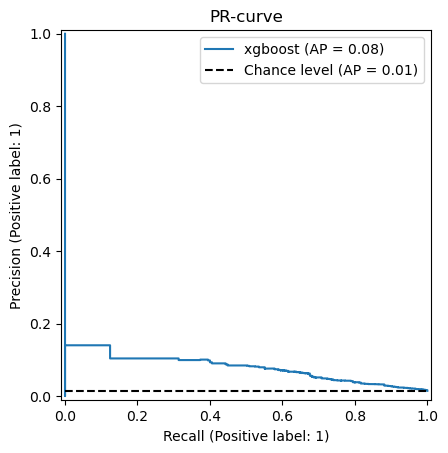

6711 0.07855808899502302


In [9]:
y_proba = pre_trained_model.predict_proba(X_test)[:, 1]

display = PrecisionRecallDisplay.from_predictions(
    y_test.T.values[0], y_proba, name="xgboost", plot_chance_level=True
)
_ = display.ax_.set_title("PR-curve")
plt.legend()
plt.show()

print((y_proba > 0.5).sum(), average_precision_score(y_test, y_proba))